# Xception — Baseline Training on Beans Dataset (Phase 2: Without Knowledge Distillation)

**Objective:** Train Xception on the Beans dataset as a baseline (no knowledge distillation) for comparison with the distilled version in Phase 3.

**Dataset:** Beans Leaf Disease Dataset (3 classes: Anthracnose, Healthy, Rust)
- ~59,069 images split 70% train / 15% validation / 15% test

**Approach:** Transfer learning with ImageNet-pretrained Xception. Base layers are frozen and a custom classification head is added for 3-class bean disease classification.

**Context:** This is Phase 2 of the project. These baseline results serve as the control group to measure the impact of cross-crop knowledge distillation in Phase 3.

## Imports and Setup

Importing required libraries and dependencies.

In [1]:
!pip install tensorflow

## Data Loading and Preprocessing

Loading the dataset and applying preprocessing (normalization, augmentation, etc.).

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

data_dir = r"C:\Users\k nithin\Downloads\M.Tech Project\Beans dataset"
img_size = 71  
batch_size = 32
seed = 123

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.30,  
    subset="training",
    seed=seed,
    image_size=(img_size, img_size),
    batch_size=batch_size,
    shuffle=True
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.30,
    subset="validation",
    seed=seed,
    image_size=(img_size, img_size),
    batch_size=batch_size,
    shuffle=True
)

val_ds = temp_ds.take(int(len(temp_ds) * 0.50))
test_ds = temp_ds.skip(int(len(temp_ds) * 0.50))

print("Train batches:", len(train_ds))
print("Validation batches:", len(val_ds))
print("Test batches:", len(test_ds))

from tensorflow.keras.applications.xception import preprocess_input

train_ds = train_ds.map(lambda x,y:(preprocess_input(x),y))
val_ds = val_ds.map(lambda x,y:(preprocess_input(x),y))
test_ds = test_ds.map(lambda x,y:(preprocess_input(x),y))

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

Found 59069 files belonging to 3 classes.
Using 41349 files for training.
Found 59069 files belonging to 3 classes.
Using 17720 files for validation.
Train batches: 1293
Validation batches: 277
Test batches: 277


## Model Architecture

Loading Xception pre-trained on ImageNet. Base layers are frozen and a custom classification head with regularization and dropout is added for 3-class classification.

In [3]:
base_model = Xception(weights='imagenet', include_top=False, input_shape=(71, 71, 3))

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.8)(x)
x = Dense(8, activation='relu', kernel_regularizer=l2(0.01))(x)
x = Dropout(0.5)(x)
predictions = Dense(3, activation='softmax', kernel_regularizer=l2(0.01))(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 71, 71, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 35, 35,    │        864 │ input_layer[0][0] │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, 35, 35,    │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, 35, 35,    │          0 │ block1_conv1_bn[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 33, 33,    │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, 33, 33,    │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, 33, 33,    │          0 │ block1_conv2_bn[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, 33, 33,    │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, 33, 33,    │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, 33, 33,    │          0 │ block2_sepconv1_… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, 33, 33,    │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, 33, 33,    │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 17, 17,    │      8,192 │ block1_conv2_act… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 17, 17,    │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 17, 17,    │        512 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 17, 17,    │          0 │ block2_pool[0][0… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, 17, 17,    │          0 │ add[0][0]       

 Total params: 20,877,899 (79.64 MB)

 Trainable params: 16,419 (64.14 KB)

 Non-trainable params: 20,861,480 (79.58 MB)

## Training

Compiling and training the model with EarlyStopping callback to prevent overfitting.

In [4]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.callbacks import ModelCheckpoint

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)
checkpoint = ModelCheckpoint(
    'Xception_beans.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)


model.compile(optimizer=Adam(learning_rate=1e-5),
              loss=SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

history = model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    callbacks=[checkpoint, early_stopping],
    shuffle = False
)

Epoch 1/10
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.3753 - loss: 1.4572
Epoch 1: val_accuracy improved from None to 0.44844, saving model to Xception_beans.keras
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 302s 231ms/step - accuracy: 0.3868 - loss: 1.4032 - val_accuracy: 0.4484 - val_loss: 1.2628
Epoch 2/10
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.4260 - loss: 1.3072
Epoch 2: val_accuracy improved from 0.44844 to 0.45363, saving model to Xception_beans.keras
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 302s 233ms/step - accuracy: 0.4287 - loss: 1.2928 - val_accuracy: 0.4536 - val_loss: 1.2438
Epoch 3/10
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 0.4481 - loss: 1.2558
Epoch 3: val_accuracy improved from 0.45363 to 0.48579, saving model to Xception_beans.keras
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 298s 231ms/step - accuracy: 0.4502 - loss: 1.2488 - val_accuracy: 0.4858 - val_loss: 1.1988
Epoch 4/10
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 0.4715 - loss: 1.

## Imports and Setup

Importing required libraries and dependencies.

In [5]:
!pip install opencv-python

## Training Results

Visualizing training and validation loss/accuracy curves to assess convergence.

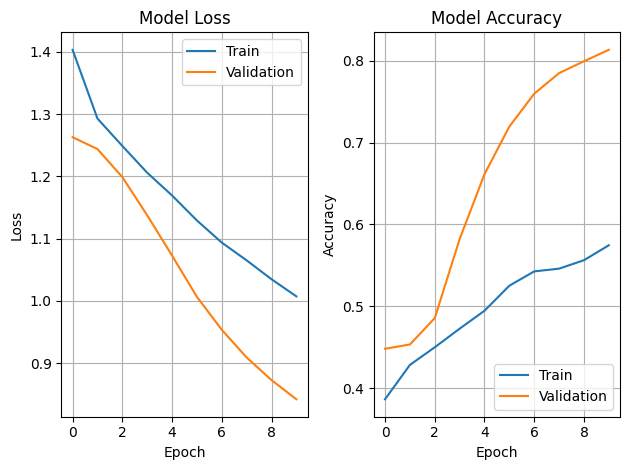

In [6]:
import os
import cv2
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import random
from PIL import Image
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'])  
plt.plot(history.history['val_accuracy']) 
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='lower right')
plt.grid(True)

plt.tight_layout()
plt.show()

## Model Evaluation

Evaluating the model performance on train, validation, and test datasets.

In [7]:
model.evaluate(test_ds)


ts_length = len(test_ds)
test_batch_size = test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
test_steps = ts_length // test_batch_size

train_score = model.evaluate(train_ds, steps= test_steps, verbose= 1)
valid_score = model.evaluate(val_ds, steps= test_steps, verbose= 1)
test_score = model.evaluate(test_ds)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

277/277 ━━━━━━━━━━━━━━━━━━━━ 58s 186ms/step - accuracy: 0.8110 - loss: 0.8445
277/277 ━━━━━━━━━━━━━━━━━━━━ 52s 185ms/step - accuracy: 0.8019 - loss: 0.8511
277/277 ━━━━━━━━━━━━━━━━━━━━ 51s 184ms/step - accuracy: 0.8132 - loss: 0.8420
277/277 ━━━━━━━━━━━━━━━━━━━━ 56s 182ms/step - accuracy: 0.8122 - loss: 0.8442
Train Loss:  0.8510562181472778
Train Accuracy:  0.8018953204154968
--------------------
Validation Loss:  0.8419679999351501
Validation Accuracy:  0.8131768703460693
--------------------
Test Loss:  0.8442148566246033
Test Accuracy:  0.8122177124023438


## Evaluation Metrics

Computing confusion matrix and classification report (precision, recall, F1-score) on the test set.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def evaluate_model(y_true, y_pred, class_names):
    """
    Plots the confusion matrix and prints the classification report.

    Args:
        y_true (array-like): True labels.
        y_pred (array-like): Predicted labels.
        class_names (list): List of class names.
    """
    cm = confusion_matrix(y_true, y_pred)

    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, target_names=class_names))


    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_percent, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix (in %)")
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.show()

## Imports and Setup

Importing required libraries and dependencies.


Classification Report:

              precision    recall  f1-score   support

      anthra       0.85      0.83      0.84      2058
     healthy       0.76      0.95      0.85      3710
        rust       0.88      0.63      0.74      3088

    accuracy                           0.81      8856
   macro avg       0.83      0.80      0.81      8856
weighted avg       0.83      0.81      0.81      8856



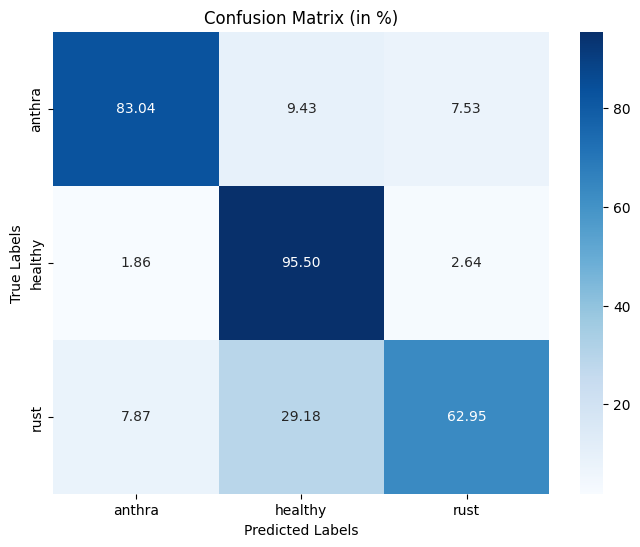

In [9]:
import numpy as np

y_true = []
y_pred = []
y_pred_probs = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    
    y_pred_probs.extend(preds)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_pred_probs = np.array(y_pred_probs)
class_names = ['anthra','healthy','rust']

evaluate_model(y_true, y_pred, class_names)

## ROC Curves

Plotting per-class ROC curves with AUC scores for the 3 bean disease classes.

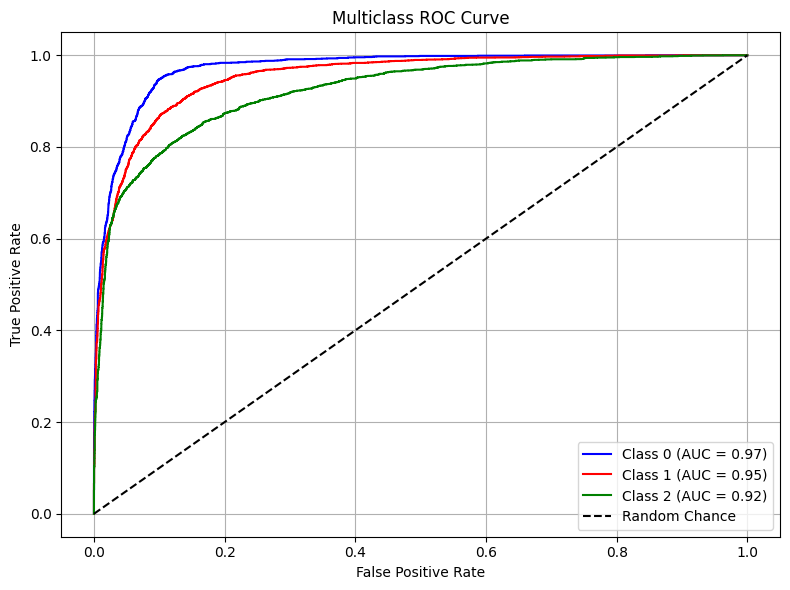

In [10]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

n_classes = y_pred_probs.shape[1]

y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))

fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
colors = ['blue', 'red', 'green', 'orange', 'purple', 'cyan']

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=colors[i % len(colors)],
             label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

## Code